# Luminosity Schechter

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Luminosity sampling

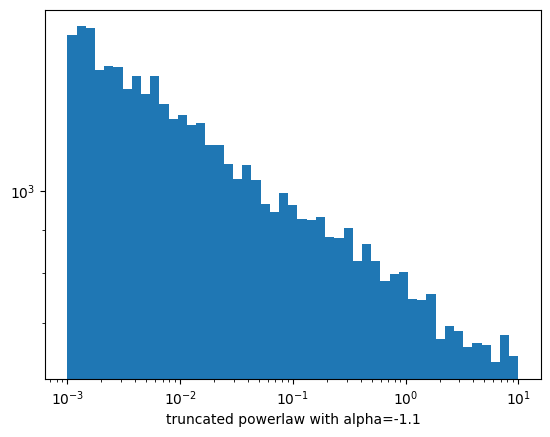

In [3]:
x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 14397


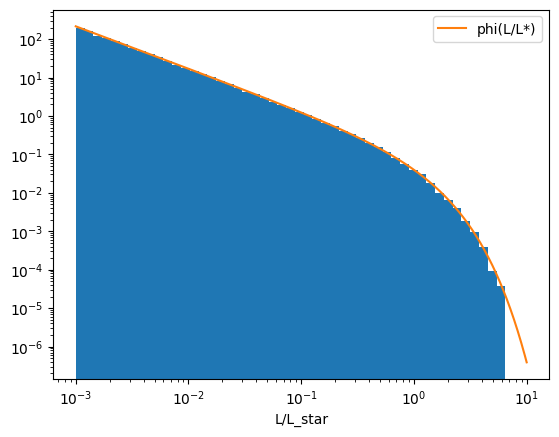

In [4]:
L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True, density=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test / np.trapz(phi_test, L_test), label = 'phi(L/L*)') #np.trapz ti normalize phi.
plt.legend();

### z, m, M, L, dL_mpc:

In [5]:
data = generate_lumMag(npix, to_table=True)
data

Number of rejects = 14364


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.016579829145377173,74.72622746036365,280356588.0471808,-16.289276914898657,18.07808837277031
0.4951261988550028,2895.021902326392,1051940827.6173291,-17.724978277866462,24.583280990816117
1.222905149061921,8721.366810790494,132036392.87633911,-15.471734128147125,29.23118863588921
0.8746792982195666,5774.290165474305,431453598.45328516,-16.757335238718504,27.050157781015752
1.0365499357093686,7114.728307614651,96496004.65386593,-15.131273330180717,29.12951827079877
0.18467941830983076,930.1856388980589,40563811.49187105,-14.190346889488998,25.65250126136445
2.3416475631760103,19317.23003155011,39331956.57725655,-14.156863877565845,32.2728603797625
1.847374460312668,14474.469726125295,151057319.7725058,-15.61785443673073,30.18515887458061


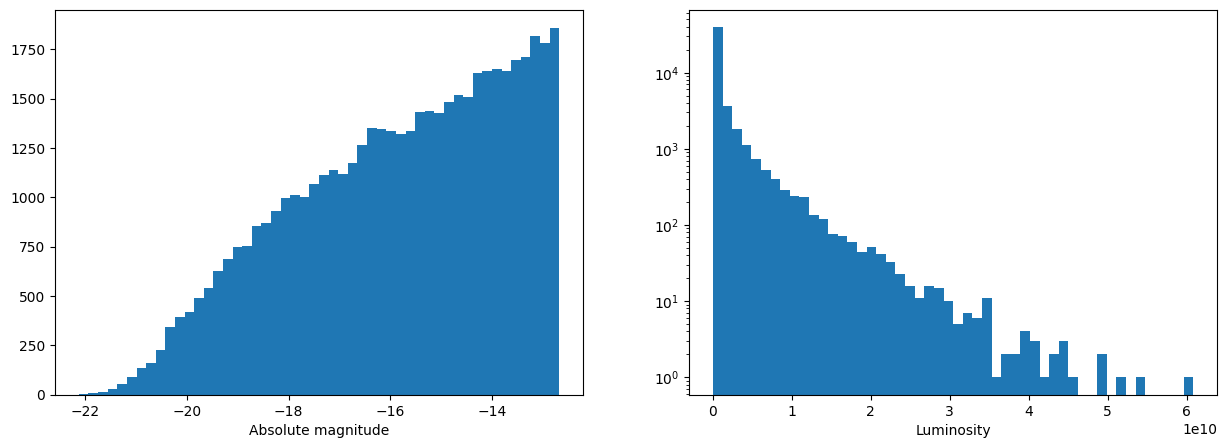

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=50, figax=(fig, ax[1]), log=True);

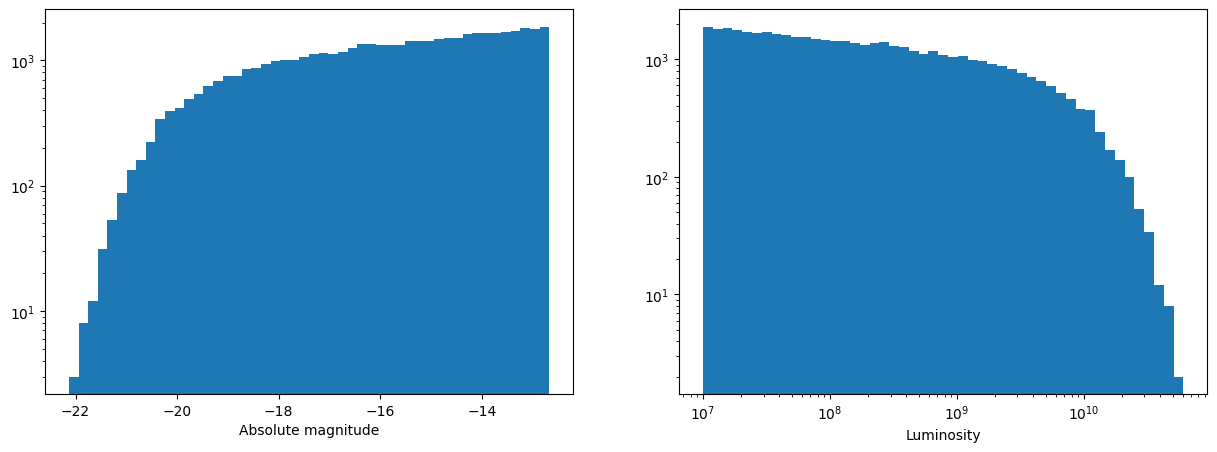

In [7]:
binsL = np.logspace(np.log10(np.min(data["L"])), np.log10(np.max(data["L"])), 50)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=binsL, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log');

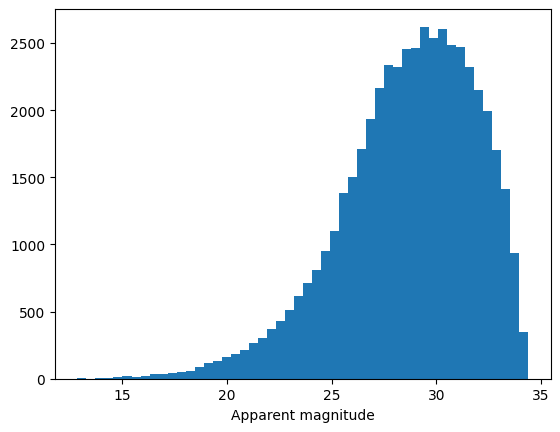

In [8]:
get_hist(data["m"], xlabel='Apparent magnitude', bins=50);

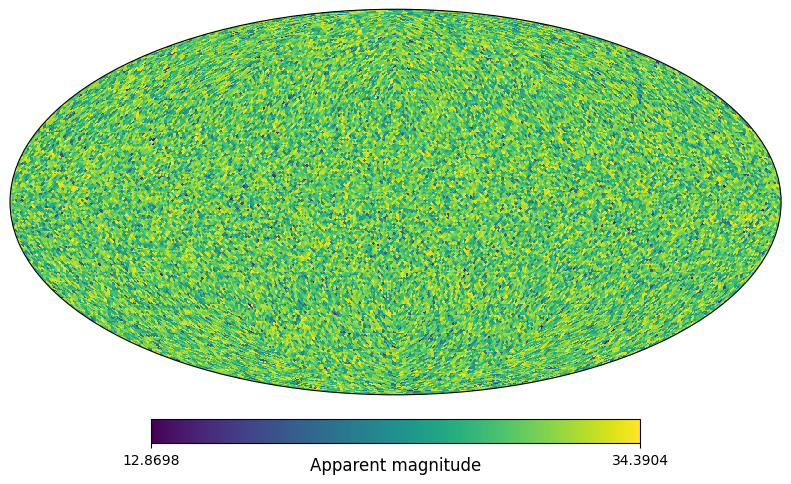

In [9]:
hp.projview(data["m"], unit="Apparent magnitude");

## $m_5$ magnitude

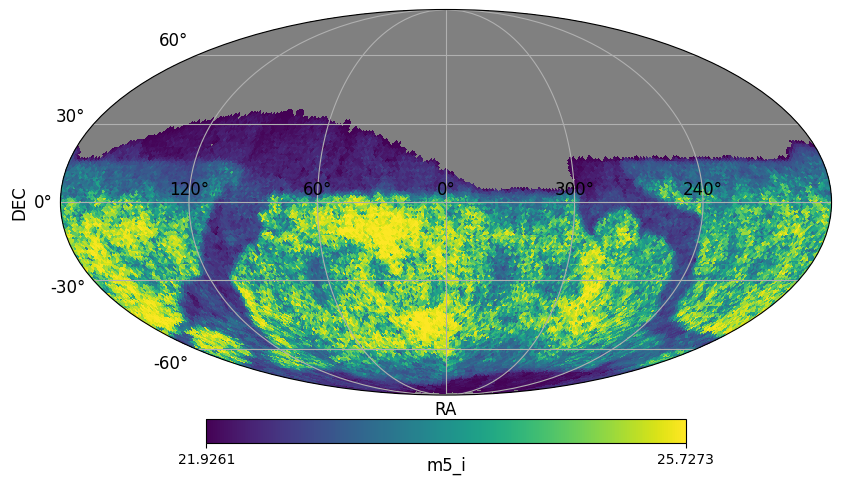

In [10]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
dm.select_band('i')
dm.set_mask()
dm.plot()

## N sources sampling

In [11]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN

Number of rejects = 297051


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.9520775752481356,15482.468823497438,31644067.380315647,-13.9207307514839,32.02847031931098
2.649020712979565,22423.263729478094,113897946.119522,-15.311289731685887,31.442204392691913
2.271938543047023,18622.090867541803,423424522.7724849,-16.73694001680392,29.61320219060539
0.9082371873180787,6047.492154447265,3653681123.8807187,-19.07682660372216,24.83104996434741
1.0060497771281045,6857.9462028342305,18647135.850125585,-13.346530337009279,30.8344400328347
1.8734119000976648,14724.150152482378,443246091.0874125,-16.786612285799976,29.053538902212686
2.105827993995387,16980.88503444989,16882363.935466677,-13.238583145452766,32.91121846299187
1.6640917374857702,12736.679577677703,330288455.4033714,-16.46723348507448,29.058047630964495


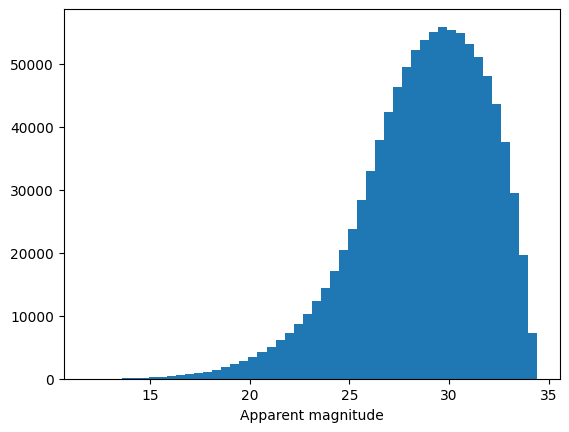

In [12]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50);

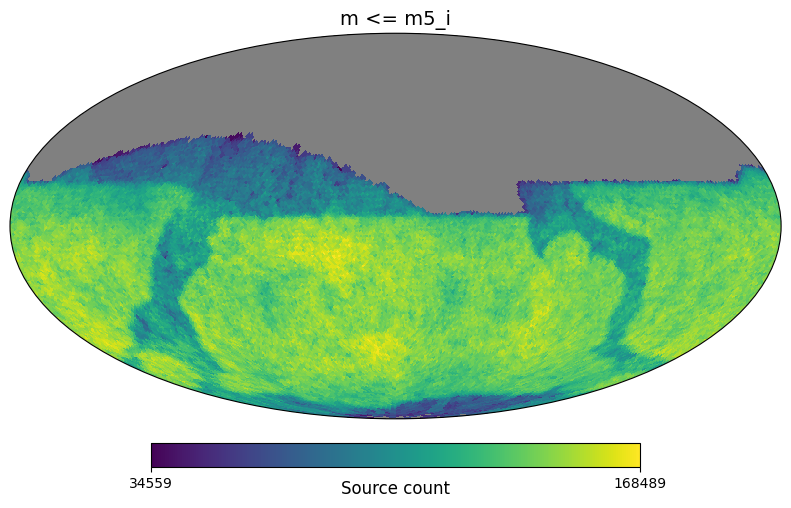

In [13]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
NSource_px = hp.ma(NSource_px, badval=0)
hp.projview(NSource_px, nest=True, unit="Source count", title= "m <= m5_i");

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.524e+08 (χ²/ndof = 3101.4)│              Nfcn = 565              │
│ EDM = 2.49e-05 (Goal: 0.0002)    │            time = 6.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │115.3296e3 │ 0.0023e3  │ -0.0023e3  │  0.0023e3  │    0    │         │       │
│ 1 │ A    │ 231.27e-3 │  0.04e-3  │  -0.04e-3  │  0.04e-3   │    0    │    1    │       │
│ 2 │ ra   │  257.525  │   0.035   │   -0.035   │   0.035    │    0    │   360   │       │
│ 3 │ dec  │  -78.243  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.3    │    2.3    │ -0.04e-3  │  0.04e-3  │  -0.035   │   0.035   │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │        5.43 -57.9061e-6      0.0076     5.80e-3 │
│   A │ -57.9061e-6    1.63e-09   -110.6e-9    -99.1e-9 │
│  ra │      0.0076   -110.6e-9     0.00122     0.01e-3 │
│ dec │     5.80e-3    -99.1e-9     0.01e-3    5.24e-05 │
└─────┴─────────────────────────────────────────────────┘

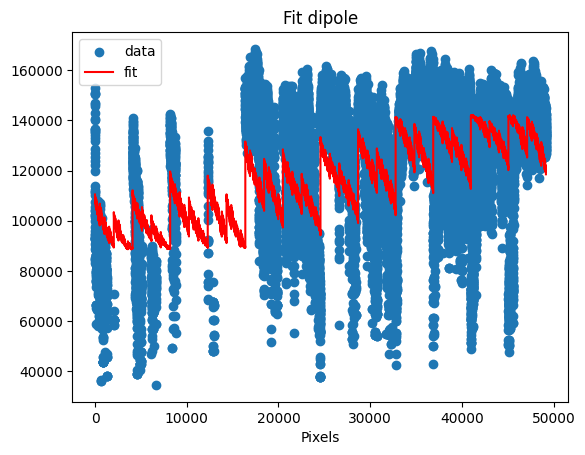

In [14]:
map = NSource_px 
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/fitMap.py:92: RuntimeWarning: invalid value encountered in sqrt
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.941e+07 (χ²/ndof = 1819.2)│              Nfcn = 676              │
│ EDM = 1.66e-09 (Goal: 0.0002)    │            time = 7.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │120.353432e3│0.000015e3 │-0.000015e3 │ 0.000015e3 │    0    │         │       │
│ 1 │ A    │197.49195e-3│0.00025e-3 │-0.00025e-3 │ 0.00025e-3 │    0    │    1    │       │
│ 2 │ ra   │    0.4    │   286.7   │    -0.4    │   286.7    │    0    │   360   │       │
│ 3 │ dec  │-89.9999999999986│0.0000006943667│-0.0000000000014│0.0000006943667│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.015   │   0.015   │ -0.25e-6  │  0.25e-6  │   -0.4    │   286.7   │ -1.4e-12  │694366.7e-12│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────┐
│     │                 M                 A                ra               dec │
├─────┼─────────────────────────────────────────────────────────────────────────┤
│   M │          0.000213         -0.12e-12          -0.02e-3           -18e-18 │
│   A │         -0.12e-12          6.37e-14        432.91e-12             0e-18 │
│  ra │          -0.02e-3        432.91e-12          6.15e+06 4.871118348547e-6 │
│ dec │           -18e-18             0e-18 4.871118348547e-6          3.87e-18 │
└─────┴─────────────────────────────────────────────────────────────────────────┘

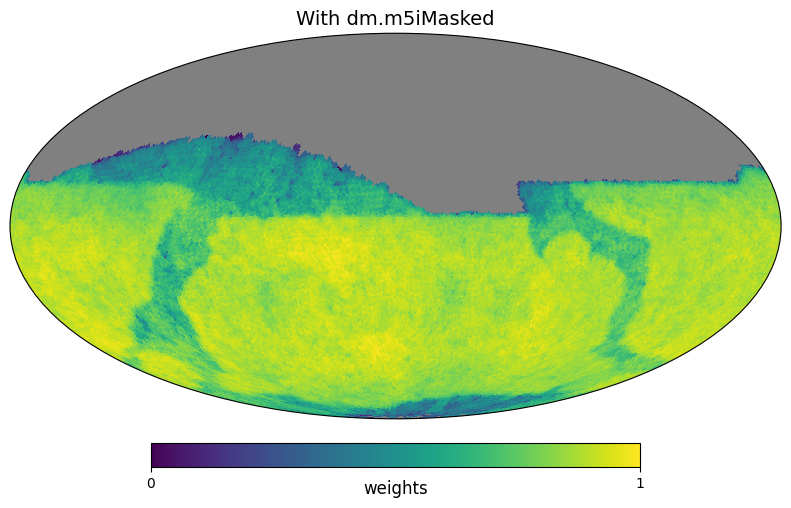

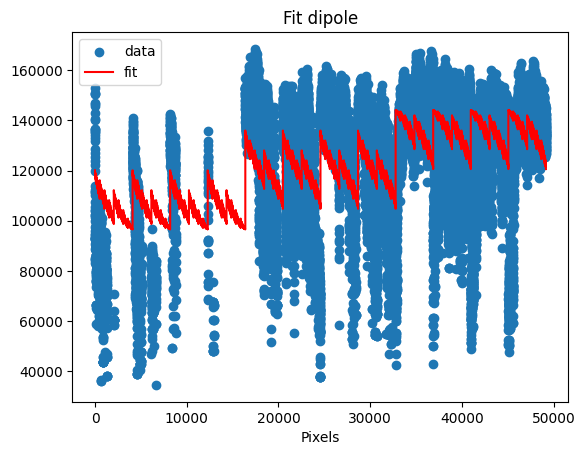

In [15]:
def renormalize(v):
    var=v.copy()
    var_min = var.min()
    var_max = var.max()
    return (var - var_min) / (var_max - var_min)


map = NSource_px
weights1 = renormalize(dm.m5iMasked)
hp.projview(weights1, nest=True, unit="weights", title= "With dm.m5iMasked");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights1)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.435e+08 (χ²/ndof = 2920.6)│              Nfcn = 555              │
│ EDM = 2.57e-05 (Goal: 0.0002)    │            time = 6.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │115.9219e3 │ 0.0024e3  │ -0.0024e3  │  0.0024e3  │    0    │         │       │
│ 1 │ A    │ 227.95e-3 │  0.04e-3  │  -0.04e-3  │  0.04e-3   │    0    │    1    │       │
│ 2 │ ra   │  258.12   │   0.04    │   -0.04    │    0.04    │    0    │   360   │       │
│ 3 │ dec  │  -78.394  │   0.007   │   -0.007   │   0.007    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.4    │    2.4    │ -0.04e-3  │  0.04e-3  │   -0.04   │   0.04    │  -0.007   │   0.007   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │           M           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│   M │         5.7 -61.2819e-6      0.0079     6.06e-3 │
│   A │ -61.2819e-6     1.7e-09   -115.0e-9   -102.9e-9 │
│  ra │      0.0079   -115.0e-9     0.00131     0.01e-3 │
│ dec │     6.06e-3   -102.9e-9     0.01e-3    5.51e-05 │
└─────┴─────────────────────────────────────────────────┘

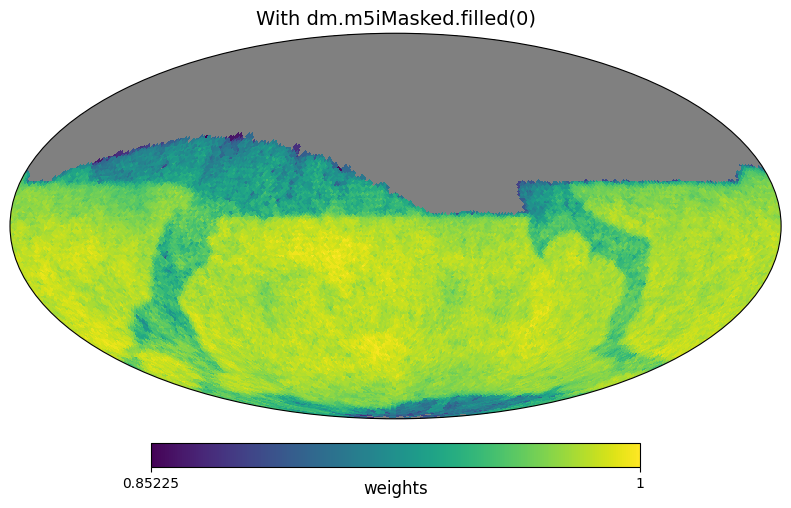

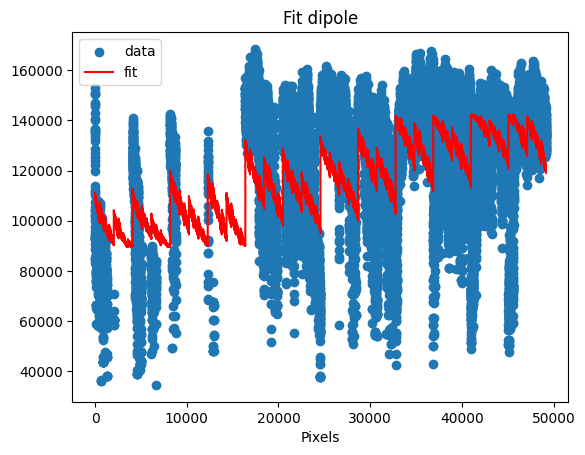

In [16]:
map = NSource_px
weights2 = renormalize(dm.m5iMasked.filled(0))
weights2 = hp.ma(weights2)
weights2.mask = dm.m5iMasked.mask
hp.projview(weights2, nest=True, unit="weights", title= "With dm.m5iMasked.filled(0)");

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, cut_masked=True, frame='icrs', contrast=False)
init =  (1000, 1, 100, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), weights=weights2)
m

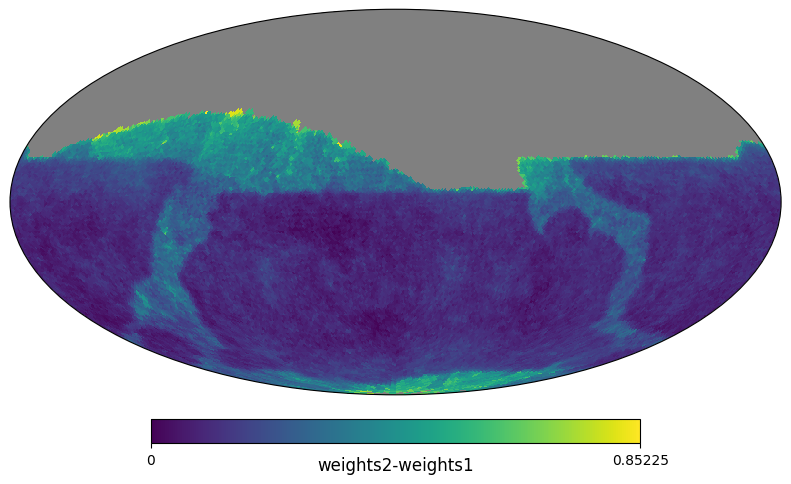

In [17]:
hp.projview(weights2-weights1, nest=True, unit="weights2-weights1", title= "");